In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from eals_radcliff.models.LMM import model as lmm_model

# ALSFRS-R

In [4]:
feature='ALS_total'
XLIM = (-.1, 2)
YLIM = (0, 1.7)

### RAPA

In [5]:
df_als = load_alsfrsr_data()
df_als[f'{feature}_zscore'] = (df_als[feature] - df_als[feature].mean()) / df_als[feature].std()
print(f'N pALS: {df_als.user_id.nunique()}, N sessions: {df_als.session_id.nunique()}')
df_als.head(2)

N pALS: 17, N sessions: 142


,speech,salvation,swallowing,handwriting,cutting_food_a,cutting_food_b,dressing_and_hygiene,turning_in_bed,walking,climbing_stairs,dyspnea,orthopnea,respiratory_insufficiency,ALS_total,created_at,user_id,date,bulbar_subscore,respiratory_subscore,fine_motor_subscore,gross_motor_subscore,session_id,months_since_first_session,years_since_first_session,ALS_total_zscore
0,4,4,4,3,3.0,NaN,3,3,3,1,4,3,4,39,2024-05-24 15:45:27+00:00,a07848cb-83b1-48ef-a314-ae5b5e5d448b,2024-05-24,12,11,NaN,7,a07848cb-83b1-48ef-a314-ae5b5e5d448b__2024-05-24,0.0,0.0,1.337840
1,4,4,4,3,2.0,4.0,2,3,2,1,4,0,2,31,2024-05-24 18:31:52+00:00,cee20458-8561-4496-932c-6855e6299641,2024-05-24,12,6,11.0,6,cee20458-8561-4496-932c-6855e6299641__2024-05-24,0.0,0.0,0.400857


ALS_total ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         ALS_total
No. Observations:          142             Method:                     REML     
No. Groups:                17              Scale:                      4.6782   
Min. group size:           1               Log-Likelihood:             -345.2850
Max. group size:           30              Converged:                  Yes      
Mean group size:           8.4                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             24.426    2.075 11.770 0.000 20.359 28.493
years_since_first_session             -1.632                   

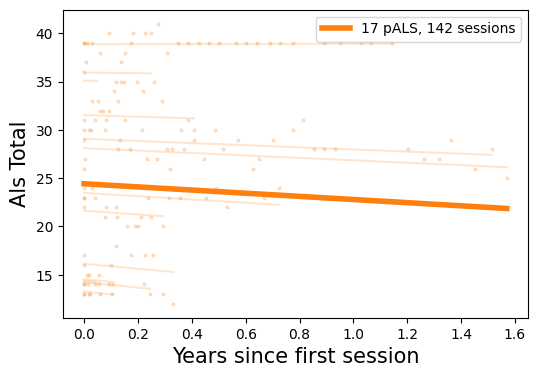

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 142 sessions	24.426 (2.075)	-1.632 (nan)


In [6]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als,#.query('ALS_total>0'),
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

ALS_total_zscore ~ years_since_first_session
1 + years_since_first_session


                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       ALS_total_zscore
No. Observations:       142           Method:                   REML            
No. Groups:             17            Scale:                    0.0642          
Min. group size:        1             Log-Likelihood:           -45.0505        
Max. group size:        30            Converged:                Yes             
Mean group size:        8.4                                                     
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.369    0.243 -1.519 0.129 -0.845  0.107
years_since_first_session             -0.191                                    
Group Var                              0.989    1.

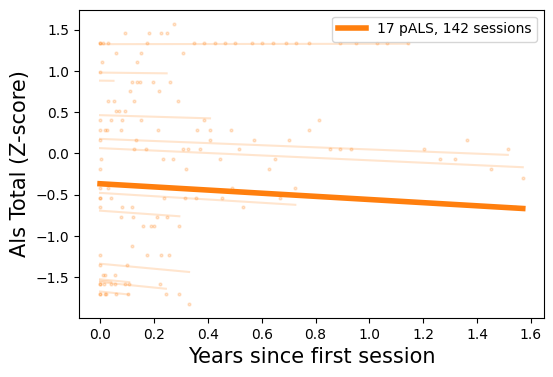

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 142 sessions	-0.369 (0.243)	-0.191 (nan)


In [7]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()} (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_als,
    dependant_variable= f'{feature}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

# ROADS

In [8]:
df_roads = load_roads_data()
df_roads['total_zscore'] = (df_roads['total'] - df_roads['total'].mean()) / df_roads['total'].std()
# Compute months since the first session per user (vectorized)
first_date = df_roads.groupby('user_id')['date'].transform('min')
months = (df_roads['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_roads.loc[:, 'months_since_first_session'] = months
df_roads.loc[:, 'years_since_first_session'] = df_roads['months_since_first_session'] / 12.0

total ~ years_since_first_session
1 + years_since_first_session


                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         total    
No. Observations:           144             Method:                     REML     
No. Groups:                 17              Scale:                      8.8340   
Min. group size:            1               Log-Likelihood:             -398.0855
Max. group size:            30              Converged:                  Yes      
Mean group size:            8.5                                                  
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              23.564    2.742  8.595 0.000 18.191 28.937
years_since_first_session              -2.222    2.936 -0.757 0.449 -7.975  3.532
Group Var                             

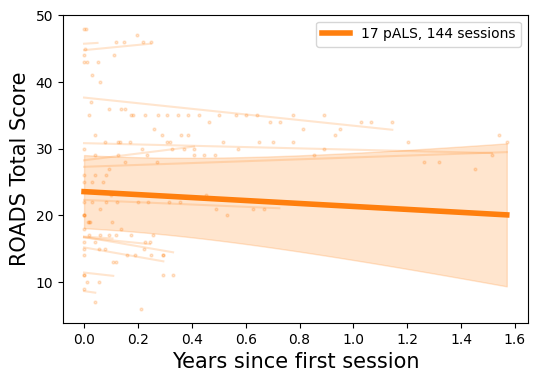

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 144 sessions	23.564 (2.742)	-2.222 (2.936)


In [9]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score"
result_dict = lmm_model.run_lmm_analysis(
    df_roads.query('total<55'),
    dependant_variable= 'total',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

total_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        total_zscore
No. Observations:         144            Method:                    REML        
No. Groups:               17             Scale:                     0.0872      
Min. group size:          1              Log-Likelihood:            -70.1728    
Max. group size:          30             Converged:                 Yes         
Mean group size:          8.5                                                   
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.376    0.272 -1.382 0.167 -0.910  0.158
years_since_first_session             -0.221    0.292 -0.757

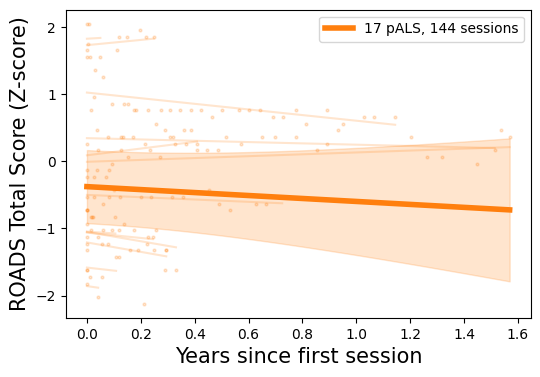

Population	Intercept (SE)	Slope (SE) (1/Years)
17 pALS, 144 sessions	-0.376 (0.272)	-0.221 (0.292)


In [10]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_roads.query('total<55'), #weird outlier
    dependant_variable= 'total_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

# Zephyr X

In [30]:
### B. Paper-like
at_least_efforts_fvc_usable=3
keep_usable_sessions_only=True
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True

df_zephyrx_new = load_zephyrx_data(
    at_least_efforts_fvc_usable=at_least_efforts_fvc_usable,
    keep_usable_sessions_only=keep_usable_sessions_only,
    at_least_months_in_study=at_least_months_in_study,
    at_least_n_sessions=at_least_n_sessions,
    multiply_by_100=multiply_by_100,
)
print(f'N pALS: {df_zephyrx_new.user_id.nunique()}, N sessions: {df_zephyrx_new.session_id.nunique()}')

# Keep only one spirometry per session (best one)
df_best_fvc_per_session = df_zephyrx_new.query('pftType=="fvc"').sort_values(['user_id', 'fvcPercPred_2019'], ascending=False).groupby('session_id').first().reset_index()
df_best_svc_per_session = df_zephyrx_new.query('pftType=="svc"').sort_values(['user_id', 'vcPercPred'], ascending=False).groupby('session_id').first().reset_index()
df_zephyrx_new = pd.concat([df_best_fvc_per_session, df_best_svc_per_session])

# Compute months since the first session per user (vectorized)
first_date = df_zephyrx_new.groupby('user_id')['date'].transform('min')
months = (df_zephyrx_new['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_zephyrx_new.loc[:, 'months_since_first_session'] = months
df_zephyrx_new.loc[:, 'years_since_first_session'] = df_zephyrx_new['months_since_first_session'] / 12.0

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    126, spiro:    295, cols: 108
2 - CRITERIA: n_fvc_atleast_usable >= 3 or vc > 0  subjects:     12, sessions:    116, spiro:    191, cols: 109
--- WARNING computing 'total_timespan' for each user after usability criteria: True
--- TOTAL TIMESPAN: min 0, max 671, mean 375.05
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 12, N sessions: 116


In [32]:
df_zephyrx_new.session_id.value_counts()

session_id
cee20458-8561-4496-932c-6855e6299641__2025-04-10    2
b96c8a5b-8902-423a-8ced-18f6b01e9885__2025-12-10    2
c2cc4d94-b103-407a-86f4-fb707b385a82__2025-06-12    2
c2cc4d94-b103-407a-86f4-fb707b385a82__2025-06-25    2
c2cc4d94-b103-407a-86f4-fb707b385a82__2025-08-04    2
                                                   ..
9485abe1-c1b5-4d27-8540-12b0f9807782__2025-10-14    1
9485abe1-c1b5-4d27-8540-12b0f9807782__2025-10-17    1
9485abe1-c1b5-4d27-8540-12b0f9807782__2025-10-28    1
9485abe1-c1b5-4d27-8540-12b0f9807782__2025-11-14    1
f8823c7d-30bb-47f6-855c-e71b1962f1af__2026-02-02    1
Name: count, Length: 116, dtype: int64

vcPercPred_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      vcPercPred_zscore
No. Observations:        115          Method:                  REML             
No. Groups:              12           Scale:                   0.2231           
Min. group size:         1            Log-Likelihood:          -106.0630        
Max. group size:         26           Converged:               Yes              
Mean group size:         9.6                                                    
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.449    0.270 -1.665 0.096 -0.977  0.080
years_since_first_session             -0.456    1.268 -

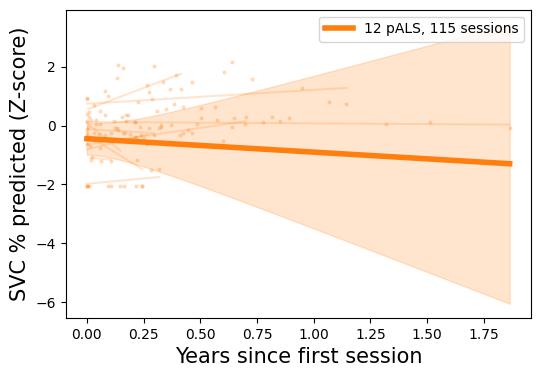

Population	Intercept (SE)	Slope (SE) (1/Years)
12 pALS, 115 sessions	-0.449 (0.270)	-0.456 (1.268)


In [29]:
# dependant_variable = 'fvcPercPred_2019'
dependant_variable = 'vcPercPred'

pftType = 'fvc' if dependant_variable.startswith('fvc') else 'svc'
df_plot = df_zephyrx_new.query('pftType==@pftType')

# Compute z score
df_plot[f'{dependant_variable}_zscore'] = (df_plot[dependant_variable] - df_plot[dependant_variable].mean()) / df_plot[dependant_variable].std()

dependant_variable_title = f"{pftType.upper()} % predicted (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_plot,
    # dependant_variable= dependant_variable,
    dependant_variable= f'{dependant_variable}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= None,
    label_false= None,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Radcliff

In [13]:
from eals_radcliff.utils import dataframes_paper

df_zephyrx_radcliff = dataframes_paper.load_zephyrx_data_paper(
    at_least_months_in_study = 2,
    at_least_n_sessions = 6,
    multiply_by_100 = True
)
df_zephyrx_radcliff.rename(columns={'patientID': 'user_id', 'date_only': 'date', 'fvcPercPred_2019': feature }, inplace=True)
df_zephyrx_radcliff[feature] /= 100

# Compute months since the first session per user
df_zephyrx_radcliff['years_since_first_session'] = df_zephyrx_radcliff['months_since_first_session'] / 12

# Keep only those similar in vcPercPred
pals_to_keep = df_zephyrx_radcliff.sort_values(['user_id','date']).groupby('user_id').vcPercPred.first()<=60
pals_to_keep = pals_to_keep[pals_to_keep].index
df_zephyrx_radcliff = df_zephyrx_radcliff.query('user_id in @pals_to_keep')

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     74, sessions:   1552, spiro:   3874, cols: 109
2 - EXCLUDING ANY OF 46 TEST USERS:                subjects:     74, sessions:   1552, spiro:   3874, cols: 109
3 - EXCLUDING ONLY ZX SESSIONS:                    subjects:     73, sessions:   1477, spiro:   3655, cols: 109
4 - AFTER PULMONOLOGIST (2023-03-01):              subjects:     70, sessions:   1397, spiro:   3486, cols: 109
5 - CRITERIA: n_fvc_atleast_usable >= 2 or vc > 0  subjects:     68, sessions:   1287, spiro:   2130, cols: 110
--- WARNING computing 'total_timespan' for each patient after usability criteria: True
--- TOTAL TIMESPAN: min 0, max 728, mean 404.46
6 - MORE THAN 2 MONTHS IN STUDY                    subjects:     47, sessions:   1241, spiro:   2048, cols: 113
7 - SUBJECTS MORE THAN 6 SESSIONS pftType          subjects:     43, sessions:   1224, spiro:   2007, cols: 114
--- ADDING

In [14]:
dependant_variable = 'vcPercPred'

pftType = 'fvc' if dependant_variable.startswith('fvc') else 'svc'

df1 = df_zephyrx_radcliff.query('pftType==@pftType')[['user_id', 'years_since_first_session', 'date', 'session_id', dependant_variable]]
df1['is_radcliff'] = True
df2 = df_zephyrx_new.query('pftType==@pftType')[['user_id', 'years_since_first_session', 'date', 'session_id', dependant_variable]]
df2['is_radcliff'] = False
df_fix = pd.concat([
    df1, 
    df2
    ], ignore_index=True)

vcPercPred ~ years_since_first_session*is_radcliff
1 + years_since_first_session
                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         vcPercPred
No. Observations:           238             Method:                     REML      
No. Groups:                 16              Scale:                      45.5447   
Min. group size:            1               Log-Likelihood:             -812.4768 
Max. group size:            40              Converged:                  Yes       
Mean group size:            14.9                                                  
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              39.198    3.886 10.087 0.000  31.581 46.814
years_since_first_session    

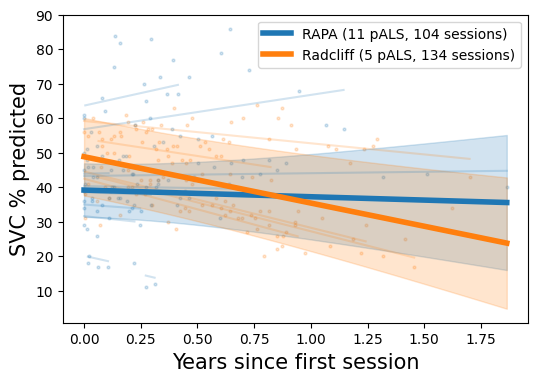

Population	Intercept (SE)	Slope (SE) (1/Years)
RAPA (11 pALS, 104 sessions)	39.198 (3.886)	-1.939 (4.823)
Radcliff (5 pALS, 134 sessions)	48.867 (5.623)	-13.443 (4.121)
Interaction	9.670 (6.817)	-11.503 (6.028)


In [15]:
label_false = 'RAPA'
label_true = 'Radcliff' 
grouping_variable = 'is_radcliff'

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"SVC % predicted"
result_dict = lmm_model.run_lmm_analysis(
    df_fix,
    dependant_variable= dependant_variable,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    label_true= label_true,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()